Bee Skilled Internship

Week 1: ML Fundamentals & Data Preprocessing

Mini Project: Titanic Survival Prediction – Data Cleaning Project

Submitted by: Divyanshi Sen

#Mini Project 1: “Titanic Survival Prediction – Data Cleaning Project”

Load Dataset

In [4]:
import pandas as pd

titanic = pd.read_csv('/content/Titanic-Dataset.csv')

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Dataset Info


In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Statistics

In [6]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Handle missing data using mean/median imputation.

Check Missing Values

In [7]:
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Mean/Median Imputation

In [8]:
# Age column
titanic['Age'] = titanic['Age'].fillna(
    titanic['Age'].median()
)

# Fare column if missing
if titanic['Fare'].isnull().sum() > 0:
    titanic['Fare'] = titanic['Fare'].fillna(
        titanic['Fare'].median()
    )

# Embarked column
titanic['Embarked'] = titanic['Embarked'].fillna(
    titanic['Embarked'].mode()[0]
)

Encode categorical variables using LabelEncoder & OneHotEncoder.

Label Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

titanic['Sex'] = label_encoder.fit_transform(
    titanic['Sex']
)

titanic['Embarked'] = label_encoder.fit_transform(
    titanic['Embarked']
)

One-Hot Encoding

In [10]:
titanic_encoded = pd.get_dummies(
    titanic,
    columns=['Embarked'],
    drop_first=True
)

titanic_encoded.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_1,Embarked_2
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,False,True


Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

titanic_encoded[['Age','Fare']] = scaler.fit_transform(
    titanic_encoded[['Age','Fare']]
)

Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X = titanic_encoded.drop('Survived', axis=1)
y = titanic_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 12)
(179, 12)


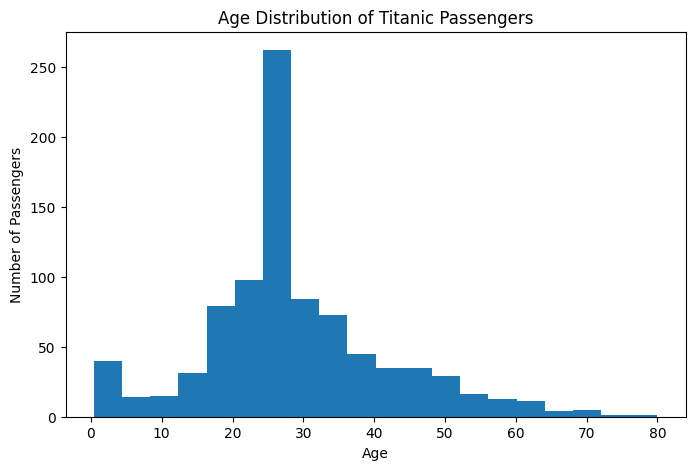

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(titanic['Age'], bins=20)

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

Cleaned Dataset Output

In [14]:
titanic_encoded.to_csv(
    'Titanic_Cleaned.csv',
    index=False
)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
